In [2]:
!pip install gymnasium torch matplotlib numpy

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque

In [4]:
N_ENVS = 32
env = gym.make_vec("Blackjack-v1", num_envs=N_ENVS, vectorization_mode="sync", sab=True)
env_single = gym.make("Blackjack-v1", sab=True)

obs, info = env.reset()
print(f"player_sum={obs[0]}, dealer_card={obs[1]}, usable_ace={obs[2]}")
print(f"{env.single_action_space.n} (0=Stick, 1=Hit)")

player_sum=[15  9 15  7 19 13 16 17 14 15 10 12 12 15 15 12 15 17 17 10 12 12  7  9
  8 12 17 10 14 20 20 16], dealer_card=[10  8  2  6 10  1  1  6  8  4 10  5  9  3  4  7  8 10  1  4 10  2 10 10
  8  3 10  1  6  2  5  8], usable_ace=[0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 (0=Stick, 1=Hit)


In [5]:
def obs_to_tensor(obs):
  if isinstance(obs, tuple):
    player_sum, dealer_card, usable_ace = obs
    return torch.FloatTensor(np.stack([
        np.array(player_sum, dtype=np.float32) / 21.0,
        np.array(dealer_card, dtype=np.float32) / 10.0,
        np.array(usable_ace, dtype=np.float32)
    ], axis=-1))
  else:
    p, d, a = obs
    return torch.FloatTensor([p / 21.0, d / 10.0, float(a)])

class Actor(nn.Module):
  def __init__(self, input_dim=3, hidden_dim=128, output_dim=2):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, output_dim),
        nn.Softmax(dim=-1)
    )

  def forward(self, x):
    return self.net(x)

class Critic(nn.Module):
  def __init__(self, input_dim=3, hidden_dim=128):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 1)
    )

  def forward(self, x):
    return self.net(x).squeeze(-1)

print(Actor())
print(Critic())

Actor(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=2, bias=True)
    (5): Softmax(dim=-1)
  )
)
Critic(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [6]:
HIDDEN_DIM = 128
GAMMA = 0.99
LR_ACTOR = 3e-4
LR_CRITIC = 1e-3
N_EPISODES = 200000
LOG_EVERY = 5000

SEED = 37
np.random.seed(SEED)
torch.manual_seed(SEED)

Обучение: Маленькая сеть (32)
Готово. Финальный avg reward: -0.0938
Обучение: Большая сеть (256)
Готово. Финальный avg reward: -0.0506
Обучение: Низкая y=0.50
Готово. Финальный avg reward: -0.0493
Обучение: Высокий lr=1e-3
Готово. Финальный avg reward: -0.0945


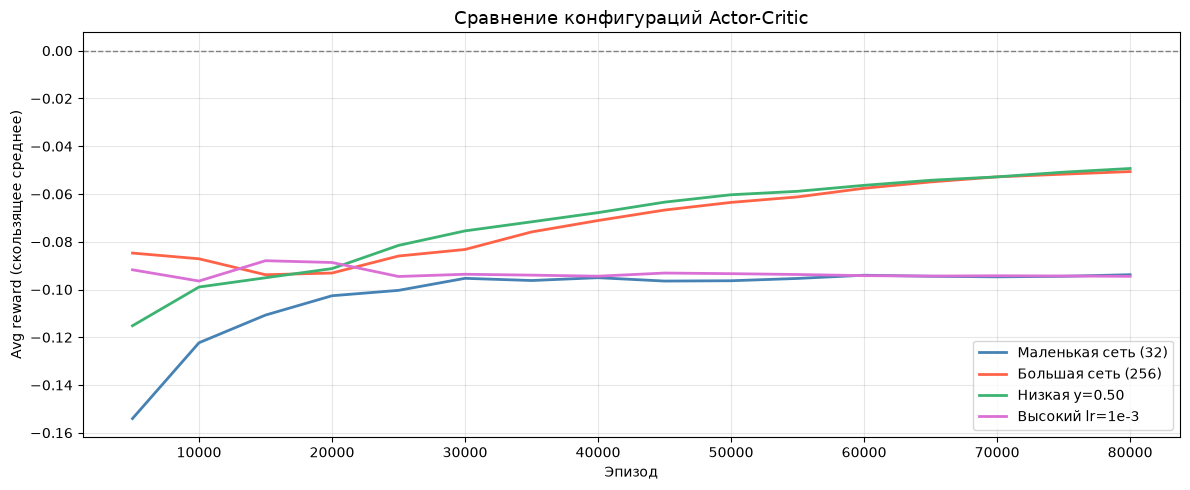

In [7]:
experiments = [
  {'name': 'Маленькая сеть (32)', 'hidden_dim': 32, 'gamma': 0.99, 'lr_actor': 3e-4, 'lr_critic': 1e-3},
  {'name': 'Большая сеть (256)', 'hidden_dim': 256, 'gamma': 0.99, 'lr_actor': 3e-4, 'lr_critic': 1e-3},
  {'name': 'Низкая y=0.50', 'hidden_dim': 128, 'gamma': 0.50, 'lr_actor': 3e-4, 'lr_critic': 1e-3},
  {'name': 'Высокий lr=1e-3', 'hidden_dim': 128, 'gamma': 0.99, 'lr_actor': 1e-3, 'lr_critic': 1e-3},
]

N_EXP_EPISODES = 80000
LOG_EXP = 5000
exp_results = {}

for cfg in experiments:
  print(f"Обучение: {cfg['name']}")

  exp_actor = Actor(hidden_dim=cfg['hidden_dim'])
  exp_critic = Critic(hidden_dim=cfg['hidden_dim'])
  exp_actor_opt = optim.Adam(exp_actor.parameters(),  lr=cfg['lr_actor'])
  exp_critic_opt = optim.Adam(exp_critic.parameters(), lr=cfg['lr_critic'])

  rewards_log = []
  reward_win = deque(maxlen=N_ENVS * LOG_EXP)

  obs, _ = env.reset()
  for step in range(1, N_EXP_EPISODES // N_ENVS + 1):
    state = obs_to_tensor(obs)
    probs = exp_actor(state)
    dist = torch.distributions.Categorical(probs)
    actions = dist.sample()
    log_prob = dist.log_prob(actions)

    next_obs, rewards, terminated, truncated, _ = env.step(actions.numpy().flatten())
    done = terminated | truncated
    next_state = obs_to_tensor(next_obs)

    value = exp_critic(state)
    with torch.no_grad():
      next_value = exp_critic(next_state)
      next_value[torch.tensor(done)] = 0.0

    target = torch.FloatTensor(rewards) + cfg['gamma'] * next_value
    advantage = target - value

    exp_critic_opt.zero_grad()
    advantage.pow(2).mean().backward()
    exp_critic_opt.step()

    exp_actor_opt.zero_grad()
    (-log_prob * advantage.detach()).mean().backward()
    exp_actor_opt.step()

    reward_win.extend(rewards.tolist())
    obs = next_obs

    if step % (LOG_EXP // N_ENVS) == 0:
      rewards_log.append(np.mean(reward_win))

  exp_results[cfg['name']] = rewards_log
  final = rewards_log[-1]
  print(f"Готово. Финальный avg reward: {final:+.4f}")

plt.figure(figsize=(12, 5))
x = [i * LOG_EXP for i in range(1, len(rewards_log) + 1)]

colors_exp = ['steelblue', 'tomato', 'mediumseagreen', 'orchid', 'orange']
for (name, rewards), color in zip(exp_results.items(), colors_exp):
  plt.plot(x, rewards, label=name, linewidth=2, color=color)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title("Сравнение конфигураций Actor-Critic", fontsize=13)
plt.xlabel("Эпизод")
plt.ylabel("Avg reward (скользящее среднее)")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
actor = Actor(hidden_dim=HIDDEN_DIM)
critic = Critic(hidden_dim=HIDDEN_DIM)

actor_optimizer = optim.Adam(actor.parameters(),  lr=LR_ACTOR)
critic_optimizer = optim.Adam(critic.parameters(), lr=LR_CRITIC)

value_history = []
reward_history = []
smoothed_values = []
smoothed_rewards = []

wins = 0
losses_count = 0
draws = 0
window = deque(maxlen=N_ENVS * LOG_EVERY)
value_window = deque(maxlen=LOG_EVERY)

obs, _ = env.reset()
for step in range(1, N_EPISODES // N_ENVS + 1):
  state = obs_to_tensor(obs)

  with torch.no_grad():
    v0 = critic(state).mean().item()
  value_window.append(v0)

  # Actor: выбираем действие
  probs = actor(state)
  dist = torch.distributions.Categorical(probs)
  actions = dist.sample()
  log_prob = dist.log_prob(actions)

  # Шаг в среде
  next_obs, rewards, terminated, truncated, _ = env.step(actions.numpy().flatten())
  done = terminated | truncated

  next_state = obs_to_tensor(next_obs)

  # Critic: V(s) и V(s')
  value = critic(state)
  with torch.no_grad():
    next_value = critic(next_state)
    next_value[torch.tensor(done)] = 0.0

  # Advantage и TD-target
  target = torch.FloatTensor(rewards) + GAMMA * next_value
  advantage = target - value

  # Потери и обновление Critic
  critic_loss = advantage.pow(2).mean() # MSE
  critic_optimizer.zero_grad()
  critic_loss.backward()
  critic_optimizer.step()

  # Потери и обновление Actor
  actor_loss = (-log_prob * advantage.detach()).mean()
  actor_optimizer.zero_grad()
  actor_loss.backward()
  actor_optimizer.step()

  window.extend(rewards.tolist())
  for r, d in zip(rewards, done):
    if d:
      if r > 0: wins += 1
      elif r < 0: losses_count += 1
      else: draws += 1

  if step % (LOG_EVERY // N_ENVS) == 0:
    avg_reward = np.mean(window)
    avg_value = np.mean(value_window)
    smoothed_rewards.append(avg_reward)
    smoothed_values.append(avg_value)
    print(f"Эпизод {step * N_ENVS:>7,} | "
          f"Avg reward: {avg_reward:+.4f} | "
          f"Avg V(s0): {avg_value:+.4f}")

  obs = next_obs

print(f"Побед={wins}, поражений={losses_count}, ничьих={draws}")

Эпизод   4,992 | Avg reward: -0.1044 | Avg V(s0): -0.2010
Эпизод   9,984 | Avg reward: -0.1057 | Avg V(s0): -0.2065
Эпизод  14,976 | Avg reward: -0.0986 | Avg V(s0): -0.1985
Эпизод  19,968 | Avg reward: -0.0968 | Avg V(s0): -0.1930
Эпизод  24,960 | Avg reward: -0.0989 | Avg V(s0): -0.1977
Эпизод  29,952 | Avg reward: -0.0970 | Avg V(s0): -0.1962
Эпизод  34,944 | Avg reward: -0.0942 | Avg V(s0): -0.1926
Эпизод  39,936 | Avg reward: -0.0907 | Avg V(s0): -0.1899
Эпизод  44,928 | Avg reward: -0.0854 | Avg V(s0): -0.1855
Эпизод  49,920 | Avg reward: -0.0814 | Avg V(s0): -0.1788
Эпизод  54,912 | Avg reward: -0.0798 | Avg V(s0): -0.1779
Эпизод  59,904 | Avg reward: -0.0764 | Avg V(s0): -0.1759
Эпизод  64,896 | Avg reward: -0.0730 | Avg V(s0): -0.1715
Эпизод  69,888 | Avg reward: -0.0708 | Avg V(s0): -0.1688
Эпизод  74,880 | Avg reward: -0.0694 | Avg V(s0): -0.1690
Эпизод  79,872 | Avg reward: -0.0667 | Avg V(s0): -0.1651
Эпизод  84,864 | Avg reward: -0.0646 | Avg V(s0): -0.1635
Эпизод  89,856

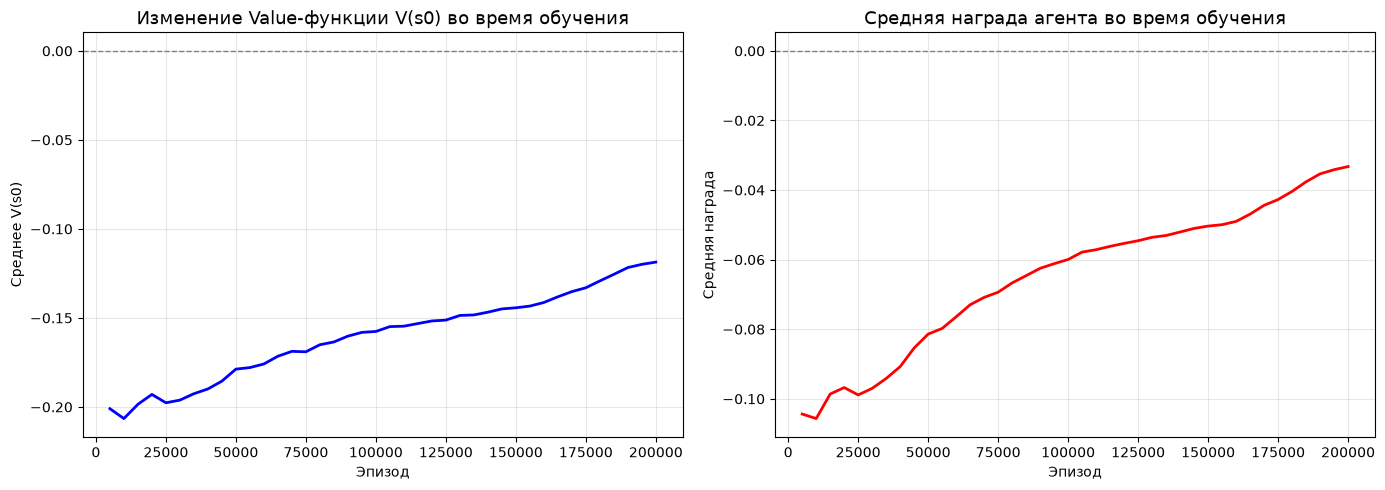

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = [i * LOG_EVERY for i in range(1, len(smoothed_values) + 1)]

# График V(s0)
axes[0].plot(x, smoothed_values, color='blue', linewidth=2)
axes[0].set_title("Изменение Value-функции V(s0) во время обучения", fontsize=13)
axes[0].set_xlabel("Эпизод")
axes[0].set_ylabel("Среднее V(s0)")
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].grid(True, alpha=0.3)

# График средней награды
axes[1].plot(x, smoothed_rewards, color='red', linewidth=2)
axes[1].set_title("Средняя награда агента во время обучения", fontsize=13)
axes[1].set_xlabel("Эпизод")
axes[1].set_ylabel("Средняя награда")
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
actor.eval()
critic.eval()

N_TEST = 100
test_wins = 0
test_losses = 0
test_draws = 0

action_log = []
game_logs = []

print(f"{'Игра':>5} | {'Ход':>4} | {'Сумма игрока':>12} | {'Карта дилера':>12} | {'Туз':>5} | {'Действие':>10} | {'Исход':>8}")
print("-" * 75)

with torch.no_grad():
  for game in range(1, N_TEST + 1):
    obs, _ = env_single.reset()
    done = False
    step = 0
    game_actions = []
    result = None

    while not done:
      step += 1
      state = obs_to_tensor(obs)
      probs = actor(state)
      action = torch.argmax(probs).item()
      action_name = "Hit " if action == 1 else "Stick"
      game_actions.append(action)

      player_sum, dealer_card, usable_ace = obs
      obs, reward, terminated, truncated, _ = env_single.step(action)
      done = terminated or truncated

      if done:
        if reward > 0: result = "Победа"
        elif reward < 0: result = "Поражение"
        else: result = "Ничья"

      print(f"{game:>5} | {step:>4} | {player_sum:>12} | {dealer_card:>12} | {str(usable_ace):>5} | {action_name:>10} | {result if done else '':>8}")

    action_log.extend(game_actions)
    game_logs.append({'game': game, 'actions': game_actions, 'result': reward})

    if reward > 0: test_wins += 1
    elif reward < 0: test_losses += 1
    else: test_draws += 1

print("-" * 75)
print(f"Победы:    {test_wins}")
print(f"Поражения: {test_losses}")
print(f"Ничьи:     {test_draws}")

 Игра |  Ход | Сумма игрока | Карта дилера |   Туз |   Действие |    Исход
---------------------------------------------------------------------------
    1 |    1 |           14 |            2 |     0 |      Stick | Поражение
    2 |    1 |           20 |            7 |     1 |      Stick |   Победа
    3 |    1 |           13 |            7 |     0 |      Stick | Поражение
    4 |    1 |            7 |            2 |     0 |       Hit  |         
    4 |    2 |           15 |            2 |     0 |      Stick | Поражение
    5 |    1 |           13 |            7 |     0 |      Stick | Поражение
    6 |    1 |           14 |           10 |     0 |      Stick | Поражение
    7 |    1 |           16 |            4 |     0 |      Stick |   Победа
    8 |    1 |           15 |           10 |     0 |      Stick | Поражение
    9 |    1 |           18 |            6 |     0 |      Stick |   Победа
   10 |    1 |           12 |           10 |     0 |       Hit  |         
   10 |    2 |    

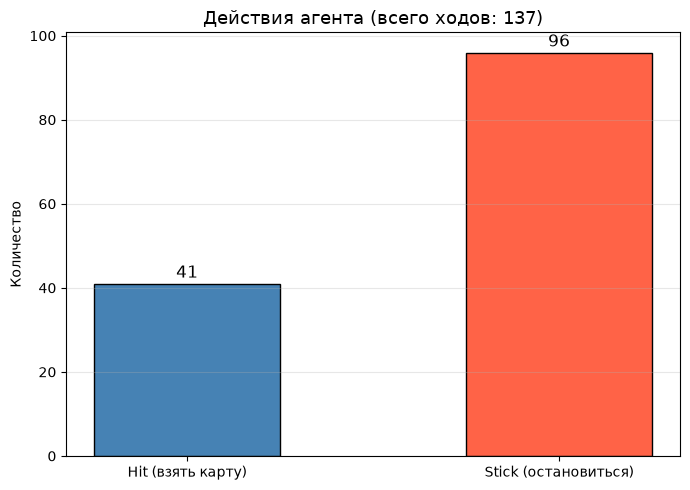

Hit:   41  (29.9% всех ходов)
Stick: 96  (70.1% всех ходов)


In [11]:
total_actions = len(action_log)
n_hit = sum(action_log)
n_stick = total_actions - n_hit

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(['Hit (взять карту)', 'Stick (остановиться)'], [n_hit, n_stick], color=['steelblue', 'tomato'], edgecolor='black', width=0.5)

for bar, val in zip(bars, [n_hit, n_stick]):
  ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val), ha='center', va='bottom', fontsize=12)

ax.set_title(f"Действия агента (всего ходов: {total_actions})", fontsize=13)
ax.set_ylabel("Количество")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Hit:   {n_hit}  ({n_hit/total_actions*100:.1f}% всех ходов)")
print(f"Stick: {n_stick}  ({n_stick/total_actions*100:.1f}% всех ходов)")

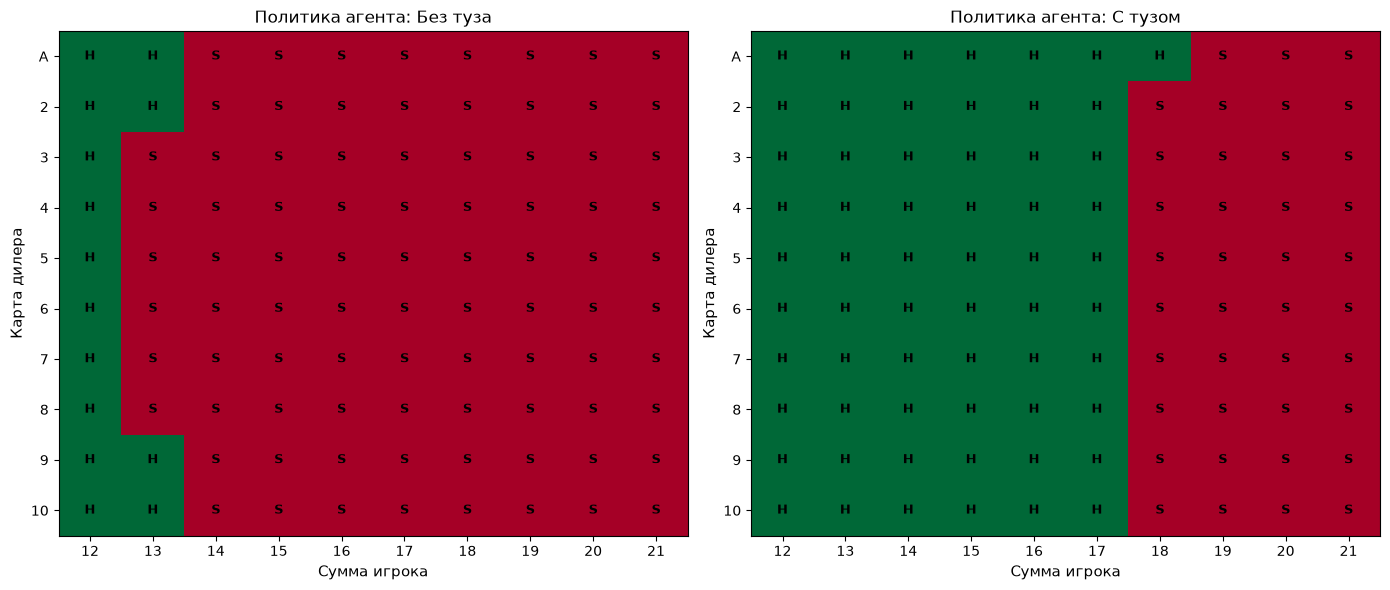

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax_idx, usable_ace in enumerate([False, True]):
  policy_grid = np.zeros((10, 10)) # dealer 1-10, player 12-21

  with torch.no_grad():
      for d_idx, dealer in enumerate(range(1, 11)):
        for p_idx, player in enumerate(range(12, 22)):
          state = torch.FloatTensor([
              player / 21.0,
              dealer / 10.0,
              float(usable_ace)
          ])
          probs = actor(state)
          action = torch.argmax(probs).item()
          policy_grid[d_idx, p_idx] = action

  im = axes[ax_idx].imshow(policy_grid, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1, origin='upper')
  axes[ax_idx].set_xticks(range(10))
  axes[ax_idx].set_xticklabels(range(12, 22))
  axes[ax_idx].set_yticks(range(10))
  axes[ax_idx].set_yticklabels(['A', 2, 3, 4, 5, 6, 7, 8, 9, 10])
  axes[ax_idx].set_xlabel("Сумма игрока", fontsize=11)
  axes[ax_idx].set_ylabel("Карта дилера", fontsize=11)
  title = "С тузом" if usable_ace else "Без туза"
  axes[ax_idx].set_title(f"Политика агента: {title}", fontsize=12)

  for i in range(10):
    for j in range(10):
      label = "H" if policy_grid[i, j] == 1 else "S"
      axes[ax_idx].text(j, i, label, ha='center', va='center', fontsize=9, fontweight='bold', color='black')

plt.tight_layout()
plt.show()